In [2]:
import sys
import herbie
import xarray as xr
import zarr as za
from herbie import Herbie
H = Herbie('2024-01-01', model='urma')
print("\n✓ STACK READY!!!!")
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

✅ Found ┊ model=urma ┊ product=anl ┊ 2024-Jan-01 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ None

✓ STACK READY!!!!


In [3]:
import xarray, zarr
print("xarray:", xarray.__version__)
print("zarr:", zarr.__version__)


xarray: 2025.11.0
zarr: 3.1.5


In [4]:
import xarray as xr

ds = xr.open_zarr(
    "01_URMA_RAW/URMA_RAW_2022_full.zarr",
    consolidated=False, zarr_format=3
)

ds


<xarray.Dataset> Size: 3GB
Dimensions:                (date: 365, y: 535, x: 457)
Coordinates:
  * date                   (date) datetime64[ns] 3kB 2022-01-01 ... 2022-12-31
    longitude              (y, x) float64 2MB dask.array<chunksize=(535, 457), meta=np.ndarray>
    atmosphereSingleLayer  float64 8B ...
    latitude               (y, x) float64 2MB dask.array<chunksize=(535, 457), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    cloud_cover_pct        (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    t2m_min_k              (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    wind_low_ms            (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    t2m_max_k              (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    dpt_afternoon_k        (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    gribfile_projection    float64 8B ...
    spfh_peak_kgkg         (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    dpt_morning_k          (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    wind_peak_ms           (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>

In [5]:
YEAR='2024'

In [6]:
# directory = f'01_URMA_RAW/URMA_RAW_2018.zarr'
# ds = xr.open_zarr('01_URMA_RAW/URMA_RAW_2018.zarr',consolidated=False)
# ds

In [7]:
ds = ds.drop_vars(["gribfile_projection","atmosphereSingleLayer"])

In [8]:
len(ds.date)

365

In [9]:
def lag1_corr(da, dim="date", spatial_dims=("y","x")):
    a = da.isel({dim: slice(None, -1)}).copy()
    b = da.isel({dim: slice(1, None)}).copy()

    # Remove coordinate alignment
    b = b.assign_coords({dim: a[dim]})

    return xr.corr(a, b, dim=dim).mean(list(spatial_dims)).compute()


In [10]:
#chck day before correllation
 
lag1_corr(ds.t2m_max_k)

<xarray.DataArray 't2m_max_k' ()> Size: 4B
array(0.92593706, dtype=float32)
Attributes: (12/39)
    GRIB_paramId:                             3015
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            max
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Maximum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [11]:
## check day before correllation

lag1_corr(ds.t2m_min_k)

<xarray.DataArray 't2m_min_k' ()> Size: 4B
array(0.92233723, dtype=float32)
Attributes: (12/39)
    GRIB_paramId:                             3016
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            min
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Minimum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [12]:
ds.t2m_max_k.isel(y=200, x=200).compute()

<xarray.DataArray 't2m_max_k' (date: 365)> Size: 1kB
array([283.17, 282.9 , 287.04, 288.16, 288.66, 287.55, 287.48, 286.2 ,
       286.69, 287.27, 288.62, 286.82, 289.7 , 288.09, 286.02, 284.65,
       290.23, 289.93, 290.29, 289.16, 289.59, 288.57, 289.4 , 291.96,
       290.67, 289.5 , 292.51, 289.92, 291.34, 288.84, 290.94, 286.47,
       286.69, 286.86, 289.37, 292.46, 290.82, 292.21, 295.31, 294.63,
       295.77, 296.9 , 297.97, 301.08, 300.16, 301.23, 287.21, 291.54,
       294.66, 294.1 , 295.37, 296.56, 288.91, 285.33, 285.86, 287.8 ,
       289.09, 291.12, 292.92, 294.99, 297.58, 299.17, 296.41, 291.2 ,
       285.96, 288.65, 290.83, 293.78, 295.65, 293.05, 296.3 , 298.2 ,
       294.95, 296.26, 295.89, 296.64, 297.38, 297.86, 292.25, 292.66,
       295.35, 300.31, 304.45, 304.6 , 303.58, 304.59, 299.55, 288.98,
       292.37, 296.65, 293.75, 298.13, 300.39, 301.53, 297.92, 297.7 ,
       301.41, 308.33, 307.81, 300.37, 296.25, 293.77, 290.99, 292.15,
       294.95, 297.39, 295.44, 298.77, 300.27, 296.75, 298.23, 295.19,
       292.8 , 296.15, 300.71, 303.56, 299.54, 299.92, 296.74, 297.99,
       301.71, 299.44, 302.37, 299.01, 304.82, 306.38, 301.81, 298.07,
       294.61, 293.06, 292.61, 294.69, 297.27, 300.45, 304.5 , 308.25,
       303.95, 303.92, 307.29, 308.2 , 300.3 , 302.98, 305.23, 307.18,
       309.06, 312.02, 307.65, 303.53, 302.05, 300.21, 301.46, 302.43,
       307.77, 306.75, 305.68, 304.5 , 305.55, 305.49, 306.7 , 307.  ,
...
       311.22, 313.41, 314.49, 311.26, 309.76, 311.18, 312.85, 312.46,
       312.32, 308.76, 308.25, 309.6 , 308.7 , 310.94, 307.5 , 309.4 ,
       309.32, 309.55, 310.71, 312.76, 313.9 , 315.18, 313.45, 313.59,
       314.68, 311.24, 310.71, 311.37, 313.36, 312.18, 313.4 , 310.26,
       307.49, 310.55, 312.21, 311.64, 313.3 , 314.8 , 312.75, 314.71,
       315.38, 318.46, 317.71, 314.39, 314.57, 309.01, 308.37, 308.36,
       306.77, 302.28, 300.98, 301.88, 303.02, 301.33, 295.96, 300.32,
       300.83, 301.26, 304.27, 307.66, 310.28, 309.81, 308.46, 307.46,
       305.13, 305.64, 305.9 , 303.58, 303.25, 305.1 , 306.48, 308.68,
       307.56, 308.57, 307.34, 306.5 , 307.15, 306.62, 304.36, 304.7 ,
       300.25, 299.28, 299.04, 301.5 , 304.53, 306.71, 307.24, 296.74,
       294.76, 296.04, 297.92, 295.38, 295.78, 299.05, 296.82, 297.29,
       294.62, 295.37, 290.1 , 287.92, 290.13, 292.26, 295.53, 289.27,
       287.74, 287.65, 287.63, 289.52, 290.47, 288.7 , 289.86, 290.18,
       292.38, 292.72, 290.4 , 291.02, 291.45, 290.12, 290.91, 290.48,
       294.42, 295.57, 293.77, 291.96, 291.53, 287.02, 291.26, 288.79,
       283.13, 290.18, 291.04, 289.33, 289.25, 286.67, 285.9 , 288.84,
       290.91, 285.22, 284.15, 284.8 , 285.08, 284.4 , 285.79, 282.78,
       278.06, 279.8 , 279.33, 279.98, 281.38, 283.44, 282.37, 283.59,
       284.12, 284.1 , 285.22, 283.86, 291.16], dtype=float32)
Coordinates:
  * date       (date) datetime64[ns] 3kB 2022-01-01 2022-01-02 ... 2022-12-31
    longitude  float64 8B 240.1
    latitude   float64 8B 35.73
Attributes: (12/39)
    GRIB_paramId:                             3015
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            max
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Maximum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [13]:
def dataset_minmax_df(ds):
    mins = ds.min().compute()
    maxs = ds.max().compute()

    rows = []

    for var in ds.data_vars:
        rows.append({
            "variable": var,
            "min": round(float(mins[var]), 4),
            "max": round(float(maxs[var]), 4)
        })

    return pd.DataFrame(rows)

In [14]:
dataset_minmax_df(ds)

,variable,min,max
0,cloud_cover_pct,0.00,100.0000
1,t2m_min_k,239.09,311.9100
2,wind_low_ms,0.00,30.7300
3,t2m_max_k,248.52,325.8100
4,dpt_afternoon_k,199.22,301.3300
5,spfh_peak_kgkg,0.00,0.0235
6,dpt_morning_k,194.70,302.0900
7,wind_peak_ms,0.00,31.7600


In [15]:
int(ds.isnull().to_array().sum().compute())

0

In [16]:
ds["cloud_cover_pct"].isnull().sum().compute()

<xarray.DataArray 'cloud_cover_pct' ()> Size: 8B
array(0)
Attributes: (12/39)
    GRIB_paramId:                             228164
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         atmosphereSingleLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_stepRange:                           0
    GRIB_units:                               %
    long_name:                                Total Cloud Cover
    units:                                    %
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [17]:
ds.isnull().any().compute()

<xarray.Dataset> Size: 8B
Dimensions:          ()
Data variables:
    cloud_cover_pct  bool 1B False
    t2m_min_k        bool 1B False
    wind_low_ms      bool 1B False
    t2m_max_k        bool 1B False
    dpt_afternoon_k  bool 1B False
    spfh_peak_kgkg   bool 1B False
    dpt_morning_k    bool 1B False
    wind_peak_ms     bool 1B False

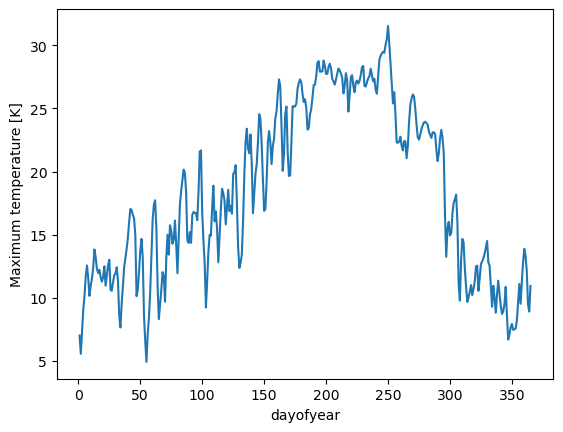

In [18]:
clim = ds.t2m_max_k.groupby("date.dayofyear").mean()
(clim - 273.15).mean(["y","x"]).plot()

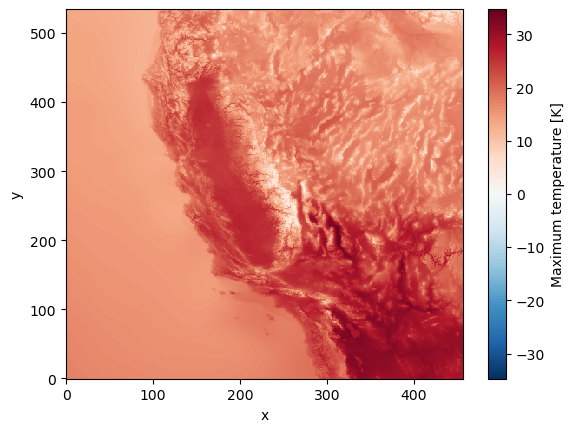

In [19]:
(ds.t2m_max_k.mean("date") - 273.15).plot()

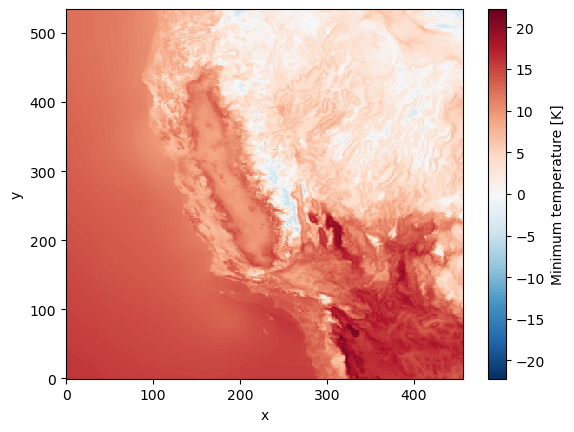

In [20]:
(ds.t2m_min_k.mean("date") - 273.15).plot()

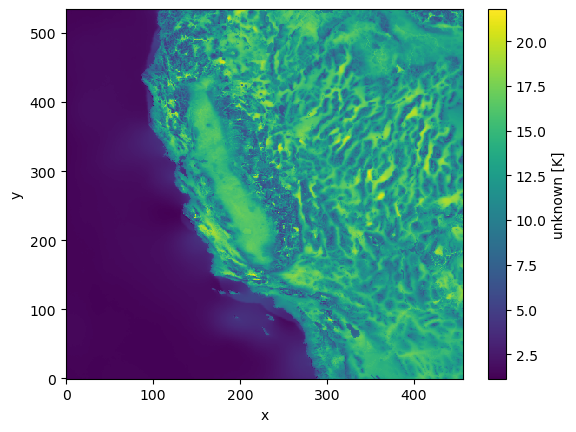

In [21]:
##Max min difference
dtr = ds.t2m_max_k - ds.t2m_min_k
dtr.mean("date").plot()

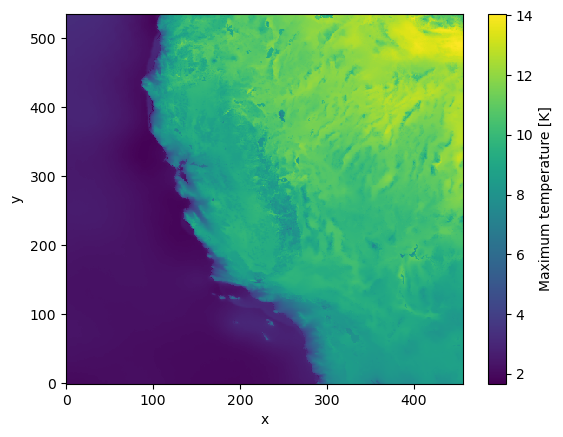

In [22]:
ds.t2m_max_k.std("date").plot()

In [23]:
clim = ds.t2m_max_k.groupby("date.dayofyear").mean("date")
anom = ds.t2m_max_k.groupby("date.dayofyear") - clim


In [24]:
anom.std("date").mean(["y","x"]).compute()


<xarray.DataArray 't2m_max_k' ()> Size: 4B
array(0., dtype=float32)
Attributes: (12/39)
    GRIB_paramId:                             3015
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            max
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Maximum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [25]:
xr.corr(ds.cloud_cover_pct, ds.t2m_max_k, dim="date").mean(["y","x"]).compute()


<xarray.DataArray ()> Size: 4B
array(-0.07640362, dtype=float32)
Attributes: (12/27)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_stepUnits:                           1
    GRIB_gridType:                            lambert
    GRIB_uvRelativeToGrid:                    1
    GRIB_DxInMetres:                          2539.703
    ...                                       ...
    GRIB_longitudeOfFirstGridPointInDegrees:  233.723448
    GRIB_longitudeOfSouthernPoleInDegrees:    0.0
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_shapeOfTheEarth:                     1
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

(array([42949481.,  5978629.,  4414446.,  3796242.,  3496919.,  3472708.,
         3861475.,  4543787.,  5390150., 11336838.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

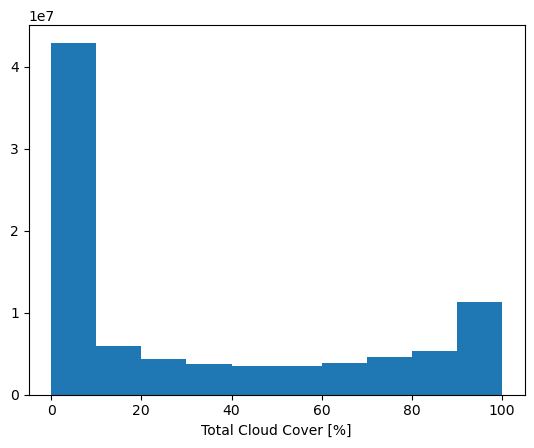

In [26]:
ds.cloud_cover_pct.plot()

(array([2.0000000e+00, 1.2000000e+01, 3.1000000e+01, 5.8500000e+02,
        2.2174000e+04, 3.4812040e+06, 2.3148504e+07, 2.4616876e+07,
        3.6729179e+07, 1.2421080e+06]),
 array([199.22000122, 209.43099976, 219.64199829, 229.85299683,
        240.06399536, 250.2749939 , 260.48599243, 270.69699097,
        280.9079895 , 291.11898804, 301.32998657]),
 <BarContainer object of 10 artists>)

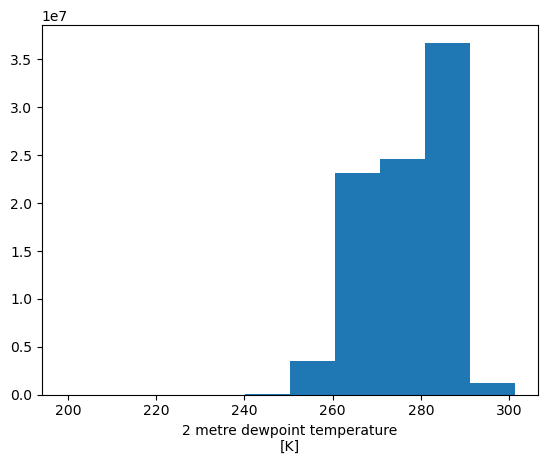

In [27]:
ds.dpt_afternoon_k.plot()

(array([1.5000000e+01, 4.9000000e+01, 5.9400000e+02, 4.8170000e+03,
        1.0906700e+05, 3.3568440e+06, 2.1450531e+07, 2.6404409e+07,
        3.6634442e+07, 1.2799070e+06]),
 array([194.69999695, 205.43899536, 216.17799377, 226.91699219,
        237.65600586, 248.39498901, 259.13400269, 269.87298584,
        280.61199951, 291.35101318, 302.08999634]),
 <BarContainer object of 10 artists>)

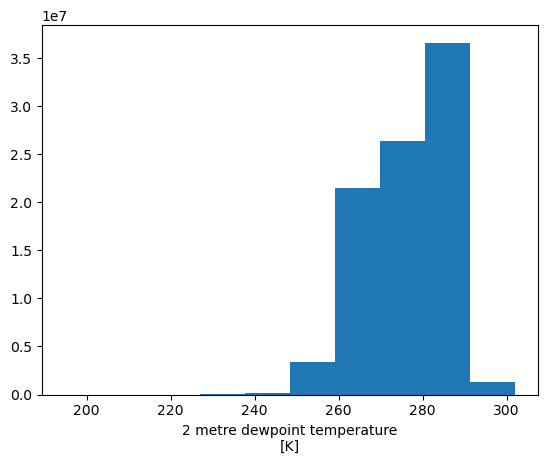

In [28]:
ds.dpt_morning_k.plot()  

(array([1.0649656e+07, 2.5452506e+07, 1.7690585e+07, 1.9479068e+07,
        1.2562556e+07, 2.8223350e+06, 4.9468400e+05, 8.2243000e+04,
        6.2220000e+03, 8.2000000e+02]),
 array([9.99999997e-07, 2.35580001e-03, 4.71059978e-03, 7.06540002e-03,
        9.42020025e-03, 1.17750000e-02, 1.41298007e-02, 1.64845996e-02,
        1.88394003e-02, 2.11942010e-02, 2.35489998e-02]),
 <BarContainer object of 10 artists>)

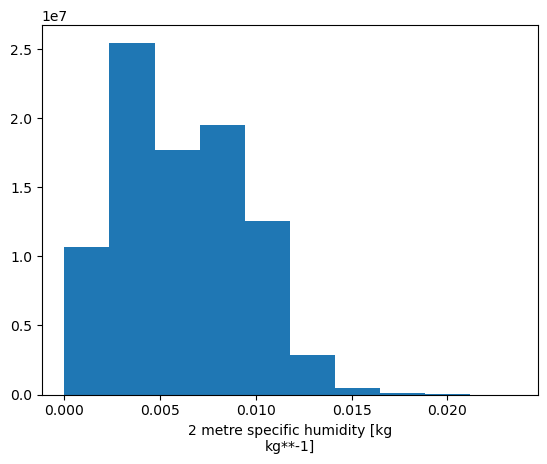

In [29]:
ds.spfh_peak_kgkg.plot()

(array([7.0300000e+02, 5.4085000e+04, 1.3877030e+06, 6.7020210e+06,
        2.1682477e+07, 3.2495670e+07, 1.2733329e+07, 1.0721164e+07,
        3.3772170e+06, 8.6306000e+04]),
 array([248.52000427, 256.24899292, 263.97799683, 271.70700073,
        279.43600464, 287.16500854, 294.89398193, 302.62298584,
        310.35198975, 318.08099365, 325.80999756]),
 <BarContainer object of 10 artists>)

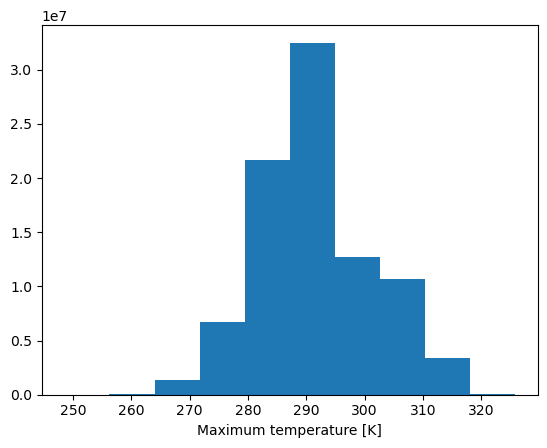

In [30]:
ds.t2m_max_k.plot()

(array([1.7610000e+03, 5.3043000e+04, 8.4904000e+05, 5.1598470e+06,
        1.2648857e+07, 1.8197489e+07, 3.8436325e+07, 1.1310276e+07,
        2.5049990e+06, 7.9038000e+04]),
 array([239.08999634, 246.37199402, 253.6539917 , 260.93600464,
        268.21798706, 275.5       , 282.78198242, 290.06399536,
        297.3460083 , 304.62799072, 311.91000366]),
 <BarContainer object of 10 artists>)

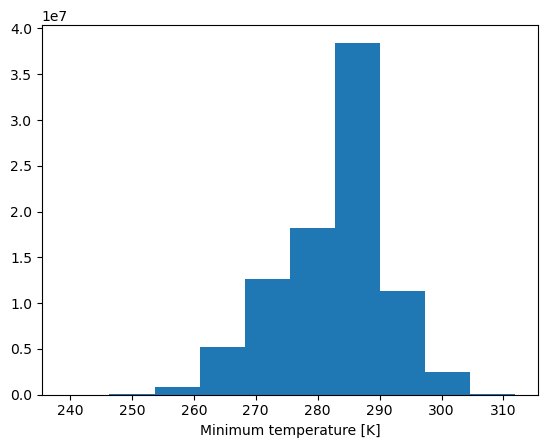

In [31]:
ds.t2m_min_k.plot()

(array([4.1337609e+07, 2.5468830e+07, 1.2791354e+07, 7.2557030e+06,
        2.1175390e+06, 2.4608600e+05, 2.0034000e+04, 3.0460000e+03,
        4.4000000e+02, 3.4000000e+01]),
 array([ 0.        ,  3.07299995,  6.14599991,  9.21899986, 12.29199982,
        15.36499977, 18.43799973, 21.51099968, 24.58399963, 27.65699959,
        30.72999954]),
 <BarContainer object of 10 artists>)

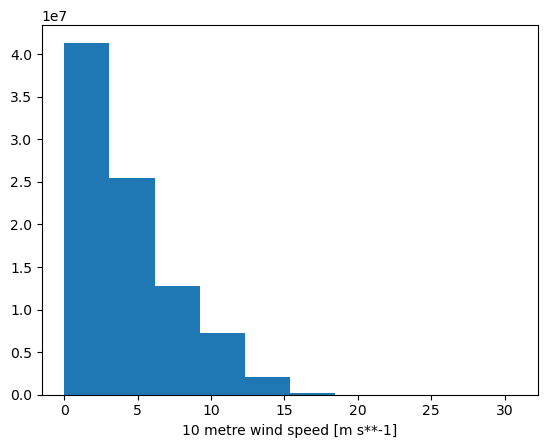

In [32]:
ds.wind_low_ms.plot()

(array([2.6853157e+07, 3.5072552e+07, 1.7889212e+07, 7.7265760e+06,
        1.5218880e+06, 1.6698600e+05, 8.8890000e+03, 1.1980000e+03,
        1.9500000e+02, 2.2000000e+01]),
 array([ 0.        ,  3.17600012,  6.35200024,  9.52799988, 12.70400047,
        15.88000107, 19.05599976, 22.23200035, 25.40800095, 28.58400154,
        31.76000023]),
 <BarContainer object of 10 artists>)

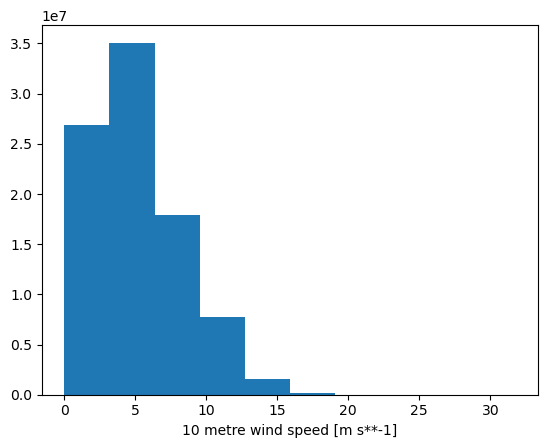

In [33]:
ds.wind_peak_ms.plot()